# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Prazos importantes

- Data de entrega: 16/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Trios

#### ALUNOS
Caio Jorge da Cunha Queiroz - 2315310028\
Lucas Maciel Gomes - 2315310014\
Izabella de Lima Catrinck - 2315310033

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [201]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from polars import DataFrame, Series
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler


In [202]:
colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]

df_train_raw = pl.read_csv("adult/adult_train.csv", has_header=False, new_columns=colunas)

df_test_raw  = pl.read_csv("adult/adult_test.csv",  has_header=False,
                            new_columns=colunas, skip_rows=1)

In [203]:
df = pl.concat([df_train_raw, df_test_raw])

In [204]:
str_cols = df.select(pl.col(pl.String)).columns
df = df.with_columns([pl.col(c).str.strip_chars() for c in str_cols])

df = df.with_columns(pl.col("income").str.replace_all(r"\.", "").alias("income"))

# fnlwgt, education-num, capital-gain, capital-loss e hours-per-week são
# colunas numéricas lidas como string por causa dos espaços originais
num_cols = ["fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df = df.with_columns([pl.col(c).cast(pl.Int64) for c in num_cols])

df.head()


age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
39,"""State-gov""",77516,"""Bachelors""",13,"""Never-married""","""Adm-clerical""","""Not-in-family""","""White""","""Male""",2174,0,40,"""United-States""","""<=50K"""
50,"""Self-emp-not-inc""",83311,"""Bachelors""",13,"""Married-civ-spouse""","""Exec-managerial""","""Husband""","""White""","""Male""",0,0,13,"""United-States""","""<=50K"""
38,"""Private""",215646,"""HS-grad""",9,"""Divorced""","""Handlers-cleaners""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States""","""<=50K"""
53,"""Private""",234721,"""11th""",7,"""Married-civ-spouse""","""Handlers-cleaners""","""Husband""","""Black""","""Male""",0,0,40,"""United-States""","""<=50K"""
28,"""Private""",338409,"""Bachelors""",13,"""Married-civ-spouse""","""Prof-specialty""","""Wife""","""Black""","""Female""",0,0,40,"""Cuba""","""<=50K"""


In [205]:
# filtros dos autores
# (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0)
df = df.filter(
    (pl.col("age")           > 16) &
    (pl.col("capital-gain")  > 100) &
    (pl.col("fnlwgt")        > 1)  &
    (pl.col("hours-per-week") > 0)
)
print(f"{len(df):>5} exemplos")

 4035 exemplos


In [206]:
# removendo dados faltantes
missing_cols = ["workclass", "occupation", "native-country"]
df = df.filter(~pl.any_horizontal([pl.col(c) == "?" for c in missing_cols]))
print(f"{len(df):>5} exemplos")

 3790 exemplos


In [207]:
df = df.with_columns((pl.col("income") == ">50K").cast(pl.Int8).alias("income"))

In [208]:
counts  = df.group_by("income").agg(pl.len().alias("n")).sort("income")
n_total = len(df)
n0, n1  = counts[0, "n"], counts[1, "n"]

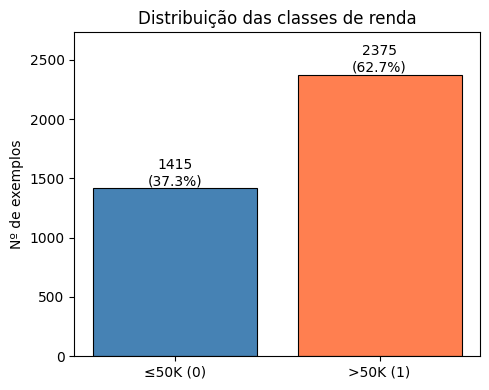

In [209]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["≤50K (0)", ">50K (1)"], [n0, n1],
              color=["steelblue", "coral"], edgecolor="black", linewidth=0.8)
ax.set_title("Distribuição das classes de renda", fontsize=12)
ax.set_ylabel("Nº de exemplos")
ax.set_ylim(0, max(n0, n1) * 1.15)
for bar, v in zip(bars, [n0, n1], strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 25,
            f"{v}\n({v/n_total*100:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Respostas da primeira seção - Abertura e Análise Exploratória

**Quantos exemplos viáveis há no dataset?**

Partimos de um total de 48.842 exemplos (32.561 do arquivo de treino + 16.281 do arquivo de teste). Após a aplicação do filtro dos autores `(age > 16) && (capital-gain > 100) && (fnlwgt > 1) && (hours-per-week > 0)`, restaram 4.035 exemplos. A maior redução foi causada pelo critério `capital-gain > 100`, já que a grande maioria das pessoas no censo possui ganho de capital igual a zero. Em seguida, removemos 245 linhas que continham valores faltantes (`'?'`), concentrados nas colunas `workclass`, `occupation` e `native-country`. Ao final, obtivemos **3.790 exemplos viáveis**.

**Preparação dos atributos**

Das 15 colunas originais, 8 são verdadeiramente categóricas (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`). As demais colunas não-alvo (`age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`) são **numéricas** e não devem ser OHE-codificadas. Após o One-Hot Encoding das 8 colunas categóricas, o dataset passou de 15 colunas para ~107 colunas (número exato depende das categorias presentes após o filtro), resultando em ~106 atributos preditores.

**O dataset é balanceado?**

Não, o dataset não é balanceado após o filtro. A distribuição fica invertida em relação ao dataset completo:

| Classe | Quantidade | Proporção |
|:-:|:-:|:-:|
| ≤50K | ~1.415 | ~37% |
| >50K | ~2.375 | ~63% |

Essa inversão ocorre porque o filtro `capital-gain > 100` seleciona pessoas com ganhos de capital significativos, que tendem a ter renda mais alta.

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

In [210]:
# one hot encoding apenas das colunas categoricas reais
categorical_cols = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]
# one hot encoding
df_encoded = df.to_dummies(columns=categorical_cols)

df_encoded = df_encoded.fill_null(0)
df_encoded = df_encoded.fill_nan(0)

n_features = df_encoded.shape[1] - 1

df_encoded.head()

age,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,fnlwgt,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,education-num,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,…,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
i64,u8,u8,u8,u8,u8,u8,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8
39,0,0,0,0,0,1,0,77516,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
31,0,0,1,0,0,0,0,45781,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,14,0,0,0,0,1,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
42,0,0,1,0,0,0,0,159449,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,1,0,0,0,0,0,0,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
30,0,0,1,0,0,0,0,188146,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,9,0,0,1,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
30,0,0,1,0,0,0,0,59496,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,1,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
X = df_encoded.drop("income").to_numpy().astype(np.float32)
y = df_encoded["income"].to_numpy().astype(np.float32)

# normalização
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [212]:
np.random.seed(42)

indices   = np.random.permutation(len(df_encoded))
split     = int(len(df_encoded) * 0.7)
train_idx = indices[:split]
test_idx  = indices[split:]

X_train_pl = X[train_idx]
X_test_pl  = X[test_idx]
y_train_pl = y[train_idx]
y_test_pl  = y[test_idx]

In [213]:
X_train_t = torch.tensor(X_train_pl, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_pl, dtype=torch.float32)

y_train_t = torch.tensor(y_train_pl, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test_pl, dtype=torch.float32).view(-1, 1)

input_size = X_train_t.shape[1]

## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [214]:
batch_size = 16

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [215]:
# definição de rede 
input_dim = X_train_t.shape[1]

class MLP1(nn.Module):
    
    def __init__(self, input_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model = MLP1(input_dim)

In [216]:
# função de perda e otimizador
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-4
)

In [217]:
# treinamento
num_epochs = 100

loss_history = []

for epoch in range(num_epochs):
    
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:

        y_batch = y_batch.view(-1,1).float()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    loss_history.append(epoch_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")



Epoch 10/100 - Loss: 0.6902
Epoch 20/100 - Loss: 0.6756
Epoch 30/100 - Loss: 0.6636
Epoch 40/100 - Loss: 0.6533
Epoch 50/100 - Loss: 0.6439
Epoch 60/100 - Loss: 0.6350
Epoch 70/100 - Loss: 0.6268
Epoch 80/100 - Loss: 0.6186
Epoch 90/100 - Loss: 0.6110
Epoch 100/100 - Loss: 0.6034


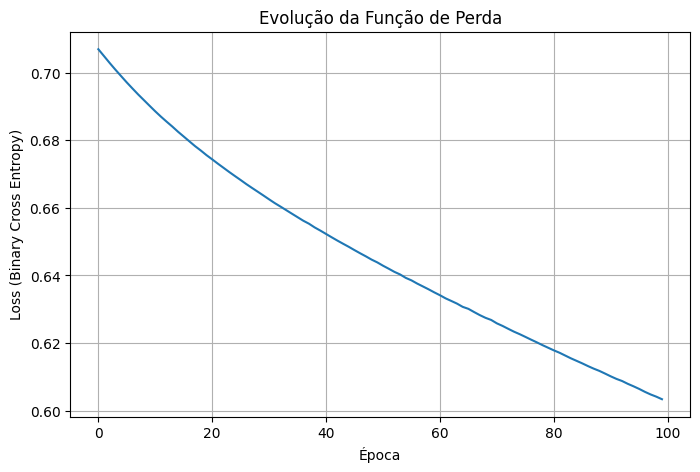

In [218]:
# gráfico de função de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Evolução da Função de Perda")
plt.grid()
plt.show() 

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.